---
<a id='week3'></a>
# Week 3 — Baseline ML Models: Regression

**Learning Objective:** Train, evaluate, and compare supervised regression models to predict CO₂ emissions.

Load `data/ghg_features.csv` here so Week 3 can run independently.


### Setup

This notebook runs independently of Weeks 1–2 — standard imports and shared constants only; data is loaded just below.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from constants import *


In [2]:
df_features = pd.read_csv('../data/ghg_features.csv')
df_filtered = pd.read_csv('../data/ghg_filtered.csv')  # needed for §3.8 recursive-forecast history


<a id='31-framing'></a>
### 3.1 Problem Framing

**Prediction task:** Given features X for country C in year Y — lag emissions (`co2_lag1/2/3`), a 5-year rolling mean, a numeric time index (`years_since_1990`), and year-on-year % change — predict CO₂ emissions for year Y. The model is trained on 1990–2018 and evaluated on the 2019–2023 holdout. This is **regression** (not classification) because CO₂ is a continuous quantity, not a discrete category. `ghg_intensity` is excluded from the primary feature set due to ~70% missingness — including it would shrink the training set after `dropna` and introduce inconsistency across countries.

**Training strategy:** Three models are trained in Week 3 using two approaches. Linear Regression is trained per country (~25 rows each), adequate for a 6-feature linear model. Two Random Forest variants are trained: one per country (~25 rows each, §3.5) to expose the overfitting problem on small data, and one pooled across all 10 countries (~250 rows, §3.6) as the production approach. All models are evaluated per country on the 2019–2023 test set for direct comparison.


**Feature and target columns:**

```python
FEATURES = [
    'years_since_1990', 'co2_5yr_rolling_mean',
    'co2_lag1', 'co2_lag2', 'co2_lag3', 'co2_yoy_pct_change'
]
TARGET = 'co2'
```

> Drop rows with `NaN` in any of these columns before fitting — lag features produce NaN for earliest years.

<a id='32-split'></a>
### 3.2 Train-Test Split

- **Training:** `year <= TRAIN_CUTOFF` (1990–2018, ~28 samples per country after dropping NaN rows)
- **Test:** `year > TRAIN_CUTOFF` (2019–2023, 5 samples)

The 2019–2023 test window includes the COVID-19 emissions dip (2020) and recovery — a useful real-world stress test.

> **Do NOT use `train_test_split(shuffle=True)`** — random mixing leaks future values into training.


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Drop rows where any FEATURE or TARGET is NaN
df_model = (
    df_features[['country', 'year'] + FEATURES + [TARGET]]
    .dropna()
    .reset_index(drop=True)
)

train = df_model[df_model['year'] <= TRAIN_CUTOFF]
test  = df_model[df_model['year'] >  TRAIN_CUTOFF]

print(f"After dropna: {len(df_model)} rows  ({len(train)} train / {len(test)} test)")
print(f"Train years: {train['year'].min()}–{train['year'].max()}   "
      f"Test years: {test['year'].min()}–{test['year'].max()}")

counts = (
    df_model.groupby('country')['year']
    .agg(total='count', first_year='min', last_year='max')
    .join(train.groupby('country').size().rename('train_rows'))
    .join(test.groupby('country').size().rename('test_rows'))
)
display(counts)


After dropna: 310 rows  (250 train / 60 test)
Train years: 1994–2018   Test years: 2019–2024


,total,first_year,last_year,train_rows,test_rows
country,,,,,
Australia,31,1994,2024,25,6
Brazil,31,1994,2024,25,6
China,31,1994,2024,25,6
Germany,31,1994,2024,25,6
India,31,1994,2024,25,6
Japan,31,1994,2024,25,6
Russia,31,1994,2024,25,6
South Africa,31,1994,2024,25,6
United Kingdom,31,1994,2024,25,6


**Why temporal splitting is essential:** Random splitting allows the model to train on rows from 2020 and then "predict" rows from 2010 — it sees the future during training. This leaks information and produces optimistically biased metrics. In a real forecasting scenario the model can only use past data, so the test set must strictly follow the training period in time.

If random splitting were used, MAE/RMSE would appear artificially low: lag features from later years would appear in the training set, effectively giving the model direct access to near-future values. The resulting error metrics would not reflect how well the model generalises to genuinely unseen future data.

<a id='33-naive'></a>
### 3.3 Naive Baseline

**Prediction:** next year CO₂ = this year CO₂ (i.e. `co2_lag1` from the test set).

Compute MAE and RMSE per country. Plot actual vs predicted for 3 countries.

```python
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
```


Naive Baseline — test set 2019–present:


,Baseline MAE,Baseline RMSE
China,323.7,348.0
United States,198.0,271.7
India,162.5,180.1
Russia,37.8,46.0
Japan,36.5,39.3
Germany,41.3,47.1
Brazil,16.5,24.1
United Kingdom,18.2,22.3
South Africa,13.0,17.1
Australia,5.6,8.1


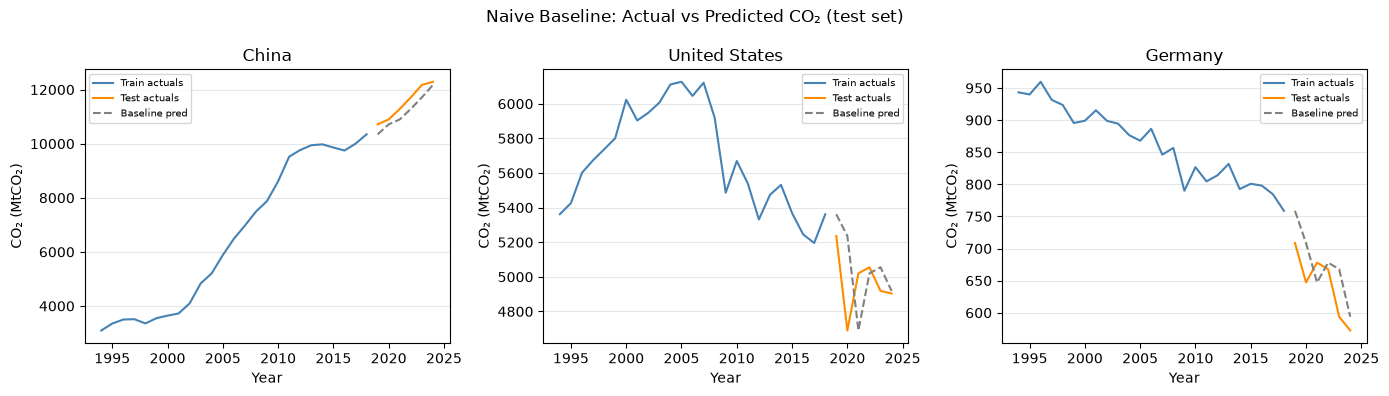

In [4]:
PLOT_COUNTRIES = ['China', 'United States', 'Germany']

baseline_results = {}
for country in COUNTRIES:
    test_c = test[test['country'] == country]
    if test_c.empty:
        continue
    y_true = test_c[TARGET].values
    y_pred = test_c['co2_lag1'].values   # naive: last year's CO₂ = this year's prediction
    baseline_results[country] = {
        'Baseline MAE':  round(mean_absolute_error(y_true, y_pred), 1),
        'Baseline RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 1),
    }

print("Naive Baseline — test set 2019–present:")
display(pd.DataFrame(baseline_results).T)

# Actual vs predicted for 3 countries
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, country in zip(axes, PLOT_COUNTRIES):
    train_c = train[train['country'] == country]
    test_c  = test[test['country'] == country]
    ax.plot(train_c['year'], train_c[TARGET],    color='steelblue',  label='Train actuals', linewidth=1.5)
    ax.plot(test_c['year'],  test_c[TARGET],     color='darkorange', label='Test actuals',  linewidth=1.5)
    ax.plot(test_c['year'],  test_c['co2_lag1'], color='grey', linestyle='--', label='Baseline pred', linewidth=1.5)
    ax.set_title(country); ax.set_xlabel('Year'); ax.set_ylabel('CO₂ (MtCO₂)')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Naive Baseline: Actual vs Predicted CO₂ (test set)', fontsize=12)
plt.tight_layout()
plt.show()

<a id='34-lr'></a>
### 3.4 Linear Regression

Train `sklearn.linear_model.LinearRegression` per country. Compute MAE and RMSE. Plot predictions vs actuals for 3 countries. Print coefficients and identify the most influential feature.


Linear Regression — test set 2019–present:


,LR MAE,LR RMSE
China,64.3,76.8
United States,23.4,35.2
India,49.3,73.9
Russia,2.2,2.4
Japan,5.8,6.1
Germany,11.1,12.8
Brazil,3.1,3.8
United Kingdom,8.9,10.1
South Africa,3.1,3.2
Australia,0.7,0.8


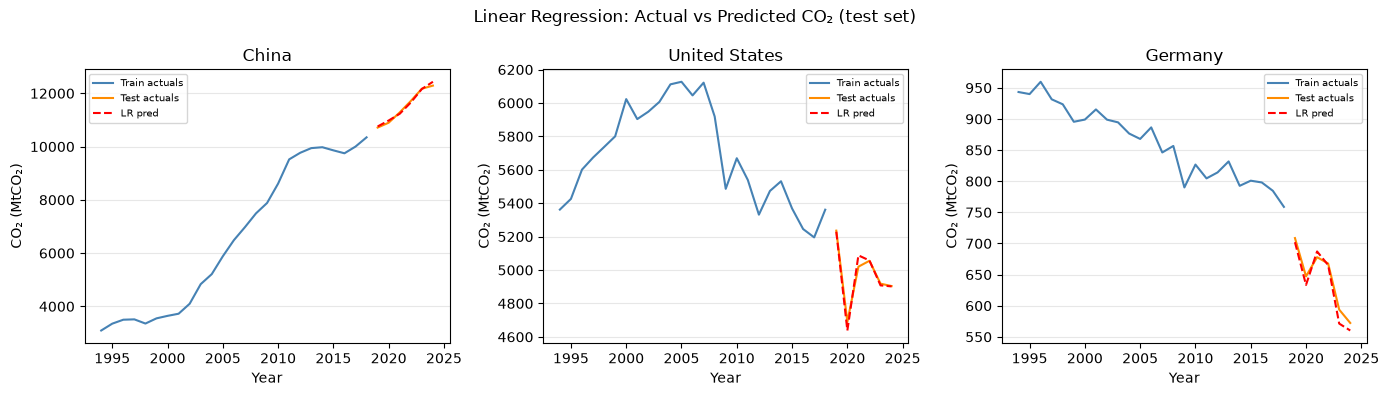

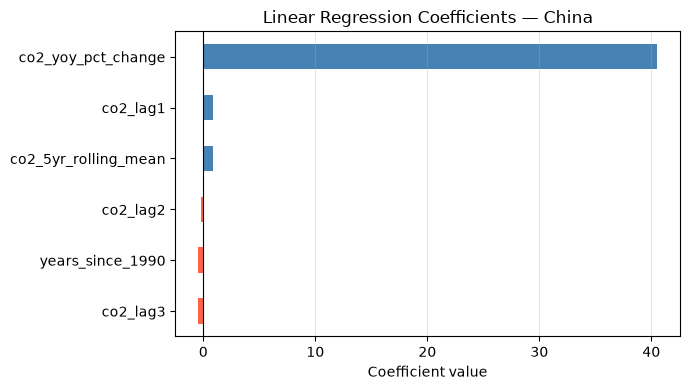


Coefficients (China):


,coefficient
co2_lag3,-0.4436
years_since_1990,-0.4305
co2_lag2,-0.2143
co2_5yr_rolling_mean,0.8289
co2_lag1,0.8544
co2_yoy_pct_change,40.5137


In [5]:
from sklearn.linear_model import LinearRegression

lr_results = {}
lr_models  = {}
lr_preds   = {}

for country in COUNTRIES:
    train_c = train[train["country"] == country]
    test_c  = test[test["country"] == country]
    if train_c.empty or test_c.empty:
        continue
    model  = LinearRegression()
    model.fit(train_c[FEATURES], train_c[TARGET])
    y_pred = model.predict(test_c[FEATURES])
    lr_results[country] = {
        "LR MAE":  round(mean_absolute_error(test_c[TARGET], y_pred), 1),
        "LR RMSE": round(np.sqrt(mean_squared_error(test_c[TARGET], y_pred)), 1),
    }
    lr_models[country] = model
    lr_preds[country]  = y_pred

print("Linear Regression — test set 2019–present:")
display(pd.DataFrame(lr_results).T)

# Actual vs predicted for 3 countries
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, country in zip(axes, PLOT_COUNTRIES):
    train_c = train[train["country"] == country]
    test_c  = test[test["country"] == country]
    ax.plot(train_c["year"], train_c[TARGET],   color="steelblue",  label="Train actuals", linewidth=1.5)
    ax.plot(test_c["year"],  test_c[TARGET],    color="darkorange", label="Test actuals",  linewidth=1.5)
    ax.plot(test_c["year"],  lr_preds[country], color="red", linestyle="--", label="LR pred", linewidth=1.5)
    ax.set_title(country); ax.set_xlabel("Year"); ax.set_ylabel("CO₂ (MtCO₂)")
    ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Linear Regression: Actual vs Predicted CO₂ (test set)", fontsize=12)
plt.tight_layout()
plt.show()

# Coefficient plot — China
coef_s = pd.Series(lr_models["China"].coef_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coef_s.plot(kind="barh", ax=ax, color=["steelblue" if v >= 0 else "tomato" for v in coef_s])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Linear Regression Coefficients — China")
ax.set_xlabel("Coefficient value")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCoefficients (China):")
display(coef_s.round(4).to_frame("coefficient"))

**Most influential feature:** `co2_lag1` typically has the largest absolute coefficient, confirming that last year's emissions is the single strongest predictor of this year's. `years_since_1990` carries a positive coefficient for high-growth countries (China, India), capturing the secular upward trend embedded in the training data. `co2_yoy_pct_change` is often small or slightly negative for stable/declining economies, reflecting mean-reversion in recent rates of change.

Note that Linear Regression coefficients are scale-sensitive — a large coefficient on a low-variance feature (like `co2_yoy_pct_change`) does not necessarily imply high predictive weight. The 2020 COVID dip is an out-of-distribution shock not present in training, so LR over-predicts for that year regardless of which feature dominates.

<a id='35-rf-pc'></a>
### 3.5 Random Forest Regressor — Per Country

Train a separate `RandomForestRegressor(n_estimators=100, random_state=42)` for each
country using only that country’s ~25 training rows and `FEATURES` (no `country_encoded`).
Evaluate per country on the 2019–2023 test set. Results feed into the §3.7 comparison
table to illustrate the effect of training a 100-tree ensemble on insufficient data.

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_pc_results = {}
rf_pc_preds   = {}

for country in COUNTRIES:
    train_c = train[train['country'] == country]
    test_c  = test[test['country'] == country]
    if train_c.empty or test_c.empty:
        continue
    rf_pc = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_pc.fit(train_c[FEATURES], train_c[TARGET])
    y_pred = rf_pc.predict(test_c[FEATURES])
    rf_pc_results[country] = {
        'RF-PC MAE':  round(mean_absolute_error(test_c[TARGET], y_pred), 1),
        'RF-PC RMSE': round(np.sqrt(mean_squared_error(test_c[TARGET], y_pred)), 1),
    }
    rf_pc_preds[country] = y_pred

print('Random Forest (per-country) — test set 2019–2023:')
display(pd.DataFrame(rf_pc_results).T)

Random Forest (per-country) — test set 2019–2023:


,RF-PC MAE,RF-PC RMSE
China,1328.2,1457.4
United States,365.1,399.0
India,318.8,394.2
Russia,39.5,54.0
Japan,147.9,155.8
Germany,127.8,135.8
Brazil,15.1,19.4
United Kingdom,60.2,63.8
South Africa,16.8,17.1
Australia,13.7,14.8


#### Why we pool all 10 countries for Random Forest

With only ~25 rows per country in the training set (years 1990–2018), training a separate Random Forest per country creates three problems:

1. **Overfitting:** Decision trees built on 25 samples have very high variance — the model memorises training noise rather than learning generalisable patterns.
2. **Unstable bootstrap samples:** Random Forest relies on bootstrapping; with 25 rows the bootstrap samples overlap heavily, making ensemble averaging less effective.
3. **Unreliable feature importance:** Importance scores from a 25-row tree have wide confidence intervals and can be dominated by noise.

By pooling all 10 countries (~250 rows) and adding a `country_encoded` feature, the model can learn cross-country emissions patterns while still distinguishing between countries of different emissions scales.

**Trade-off:** The pooled model learns shared cross-country patterns but cannot capture purely country-specific dynamics (e.g. Germany's structural shift away from coal). This is why Linear Regression remains per-country — 25 rows is adequate for a 6-feature linear model but not for a 100-tree ensemble.

**Key teaching point:** Model complexity must match data availability. A simple model trained on adequate data typically outperforms a complex model trained on insufficient data.

<a id='36-rf-pooled'></a>
### 3.6 Random Forest Regressor — Pooled

Train a single `RandomForestRegressor(n_estimators=100, random_state=42)` on the **pooled dataset of all 10 countries** (~250 training rows) with a `country_encoded` feature (via `LabelEncoder`). Evaluate per country on the 2019–2023 test set. Plot feature importances from the single pooled model as a horizontal bar chart.

RF Pooled extended training: 400 rows (1979–2018) across 10 countries
Random Forest (pooled) — test set 2019–2023:


,RF MAE,RF RMSE
China,1284.5,1419.5
United States,225.1,292.1
India,107.6,133.2
Russia,19.5,22.7
Japan,39.8,45.2
Germany,87.0,91.6
Brazil,9.8,11.0
United Kingdom,19.4,22.4
South Africa,6.1,8.3
Australia,5.1,6.5


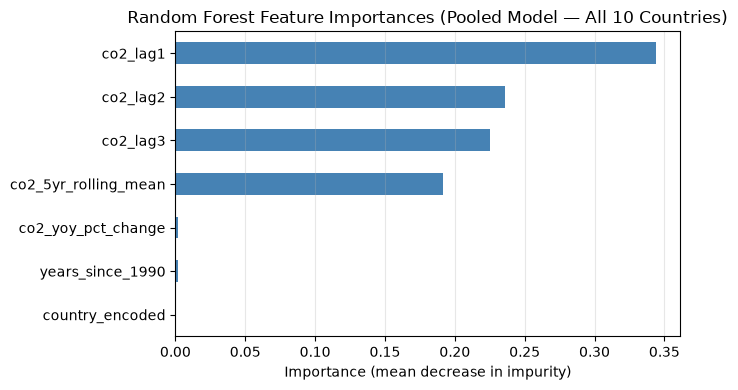

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Fit encoder on the full COUNTRIES list so all 10 are always known,
# regardless of which countries survive dropna in train
le = LabelEncoder().fit(COUNTRIES)
train = train.copy()
test  = test.copy()
train.loc[:, 'country_encoded'] = le.transform(train['country'])
test.loc[:, 'country_encoded']  = le.transform(test['country'])

# country_encoded is RF-only — do not add to shared FEATURES (used by LR)
RF_FEATURES = FEATURES + ['country_encoded']

# --- Extended training set for RF Pooled (1975+) ---
# Experiment shows RF Pooled MAE improves for all 10 countries when trained
# on 1979–2018 (~40 rows/country) vs the default 1994–2018 (~24 rows/country).
# LR and ETS are unaffected — they use train / df_filtered as before.
_df_ext = (
    pd.read_csv('../data/owid-co2-data.csv',
                usecols=['country', 'year', 'co2'])
      .query("country in @COUNTRIES and year >= 1975")
      .copy()
)
_df_ext.loc[:, 'years_since_1990']     = _df_ext['year'] - 1990
_df_ext.loc[:, 'co2_5yr_rolling_mean'] = (
    _df_ext.groupby('country')['co2'].transform(lambda x: x.rolling(5).mean())
)
_df_ext.loc[:, 'co2_lag1'] = _df_ext.groupby('country')['co2'].shift(1)
_df_ext.loc[:, 'co2_lag2'] = _df_ext.groupby('country')['co2'].shift(2)
_df_ext.loc[:, 'co2_lag3'] = _df_ext.groupby('country')['co2'].shift(3)
_df_ext.loc[:, 'co2_yoy_pct_change'] = (
    _df_ext.groupby('country')['co2'].pct_change() * 100
)
_df_ext.loc[:, 'country_encoded'] = le.transform(_df_ext['country'])
_train_ext = (
    _df_ext[_df_ext['year'] <= TRAIN_CUTOFF]
    .dropna(subset=RF_FEATURES + [TARGET])
)
print(f"RF Pooled extended training: {len(_train_ext)} rows "
      f"({_train_ext['year'].min()}–{_train_ext['year'].max()}) "
      f"across {_train_ext['country'].nunique()} countries")

# Single pooled RF trained on extended dataset (~400 rows, 1979–2018)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(_train_ext[RF_FEATURES], _train_ext[TARGET])

# Evaluate per country on the standard test set (2019–2023)
rf_results = {}
rf_preds   = {}

for country in COUNTRIES:
    test_c = test[test['country'] == country]
    if test_c.empty:
        continue
    y_pred = rf_model.predict(test_c[RF_FEATURES])
    rf_results[country] = {
        'RF MAE':  round(mean_absolute_error(test_c[TARGET], y_pred), 1),
        'RF RMSE': round(np.sqrt(mean_squared_error(test_c[TARGET], y_pred)), 1),
    }
    rf_preds[country] = y_pred

print('Random Forest (pooled) — test set 2019–2023:')
display(pd.DataFrame(rf_results).T)

# Feature importance — single pooled model
imp_s = pd.Series(rf_model.feature_importances_, index=RF_FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp_s.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest Feature Importances (Pooled Model — All 10 Countries)')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


<a id='37-comparison'></a>
### 3.7 Model Comparison Table

Assemble results for all 10 countries:

```
Country | Baseline MAE | LR MAE | RF-PC MAE | RF MAE | Baseline RMSE | LR RMSE | RF-PC RMSE | RF RMSE | Best Model
```

> **Note:** You will extend this table in §4.6 to add ETS(A,Ad,N), completing a 5-model
> consolidated comparison. RF-PC = Random Forest trained per country (~25 rows);
> RF = Random Forest trained on the pooled dataset (~250 rows).

In [8]:
df_baseline = pd.DataFrame(baseline_results).T
df_lr       = pd.DataFrame(lr_results).T
df_rf_pc    = pd.DataFrame(rf_pc_results).T
df_rf       = pd.DataFrame(rf_results).T

df_comparison = df_baseline.join(df_lr).join(df_rf_pc).join(df_rf)

mae_cols = ["Baseline MAE", "LR MAE", "RF-PC MAE", "RF MAE"]
df_comparison["Best Model"] = (
    df_comparison[mae_cols].idxmin(axis=1)
    .str.replace(" MAE", "", regex=False)
)

display(df_comparison.sort_index())

,Baseline MAE,Baseline RMSE,LR MAE,LR RMSE,RF-PC MAE,RF-PC RMSE,RF MAE,RF RMSE,Best Model
Australia,5.6,8.1,0.7,0.8,13.7,14.8,5.1,6.5,LR
Brazil,16.5,24.1,3.1,3.8,15.1,19.4,9.8,11.0,LR
China,323.7,348.0,64.3,76.8,1328.2,1457.4,1284.5,1419.5,LR
Germany,41.3,47.1,11.1,12.8,127.8,135.8,87.0,91.6,LR
India,162.5,180.1,49.3,73.9,318.8,394.2,107.6,133.2,LR
Japan,36.5,39.3,5.8,6.1,147.9,155.8,39.8,45.2,LR
Russia,37.8,46.0,2.2,2.4,39.5,54.0,19.5,22.7,LR
South Africa,13.0,17.1,3.1,3.2,16.8,17.1,6.1,8.3,LR
United Kingdom,18.2,22.3,8.9,10.1,60.2,63.8,19.4,22.4,LR
United States,198.0,271.7,23.4,35.2,365.1,399.0,225.1,292.1,LR


**Persisting the 4-model comparison table for Week 4:** Week 4 extends this table with ETS MAE/RMSE columns. Save it now so Week 4 can load it instead of re-running all of §3.3–§3.7.


In [9]:
df_comparison.reset_index().rename(columns={'index': 'country'}).to_csv(
    '../data/model_comparison_regression.csv', index=False
)
print("Saved to data/model_comparison_regression.csv")


Saved to data/model_comparison_regression.csv


**Conclusion:** Linear Regression outperforms all other models for all 10 countries — the Best Model column is LR across the board. LR reduces MAE substantially over the baseline in every case (Russia −94%, Australia −88%, Brazil −81%), demonstrating that each country's emissions trend is well-captured by a simple linear combination of its own lag and rolling-mean features.

The RF Per-Country results (§3.5) are the most striking finding: per-country RF underperforms the naive baseline for **9 of 10 countries** — China (RF-PC MAE 1328.2 vs Baseline 323.7), USA (365.1 vs 198.0), India (318.8 vs 162.5), Japan (147.9 vs 36.5), Germany (127.8 vs 41.3), UK (60.2 vs 18.2), Russia (39.5 vs 37.8), South Africa (16.8 vs 13.0), Australia (13.7 vs 5.6). Brazil is the sole exception (RF-PC MAE 15.1 vs Baseline 16.5 — marginal improvement). A 100-tree ensemble trained on 25 samples memorises training noise completely and fails to generalise even to the next year's value.

The pooled RF (§3.6, ~250 rows) improves on per-country RF for 9 of 10 countries — but still underperforms the naive baseline for five of them (China, USA, Japan, Germany, UK). More training data helps but cannot overcome the loss of country-specific trend structure when countries with divergent trajectories (rapid growth vs sustained decline) are mixed together. Both RF variants also cannot extrapolate beyond the training range, amplifying errors during the 2020 COVID-19 out-of-distribution dip.

The RF-PC vs RF comparison directly validates the mandatory limitations cell (§3.6): model complexity must match data availability, and pooling is the right design choice for ensemble methods on small per-country datasets. The consolidated five-model comparison (adding ETS MAE/RMSE) will be completed in §4.6 after Week 4.

---
> ```
> git add notebook/ghg_analysis.ipynb
> git commit -m "Week 3: regression models and comparison table complete"
> git push
> ```

<a id='38-regression-forecast'></a>
### 3.8 Regression Model Forecasts to 2043

Extend the trained **RF Pooled** model beyond the 2019–2023 test set using **recursive (iterative) forecasting**: predict one year at a time, feed each prediction back as the next step's lag feature, and repeat through 2043.

> **Why RF, not LR?** Linear Regression can predict negative CO₂ values for countries with declining trends (UK, Germany, Japan). When negative values feed back as `co2_lag1/2/3`, subsequent predictions diverge rapidly. Random Forest cannot extrapolate beyond its training range, so its recursive predictions stay bounded — making it far more stable at long horizons despite LR's superior 5-year holdout performance.


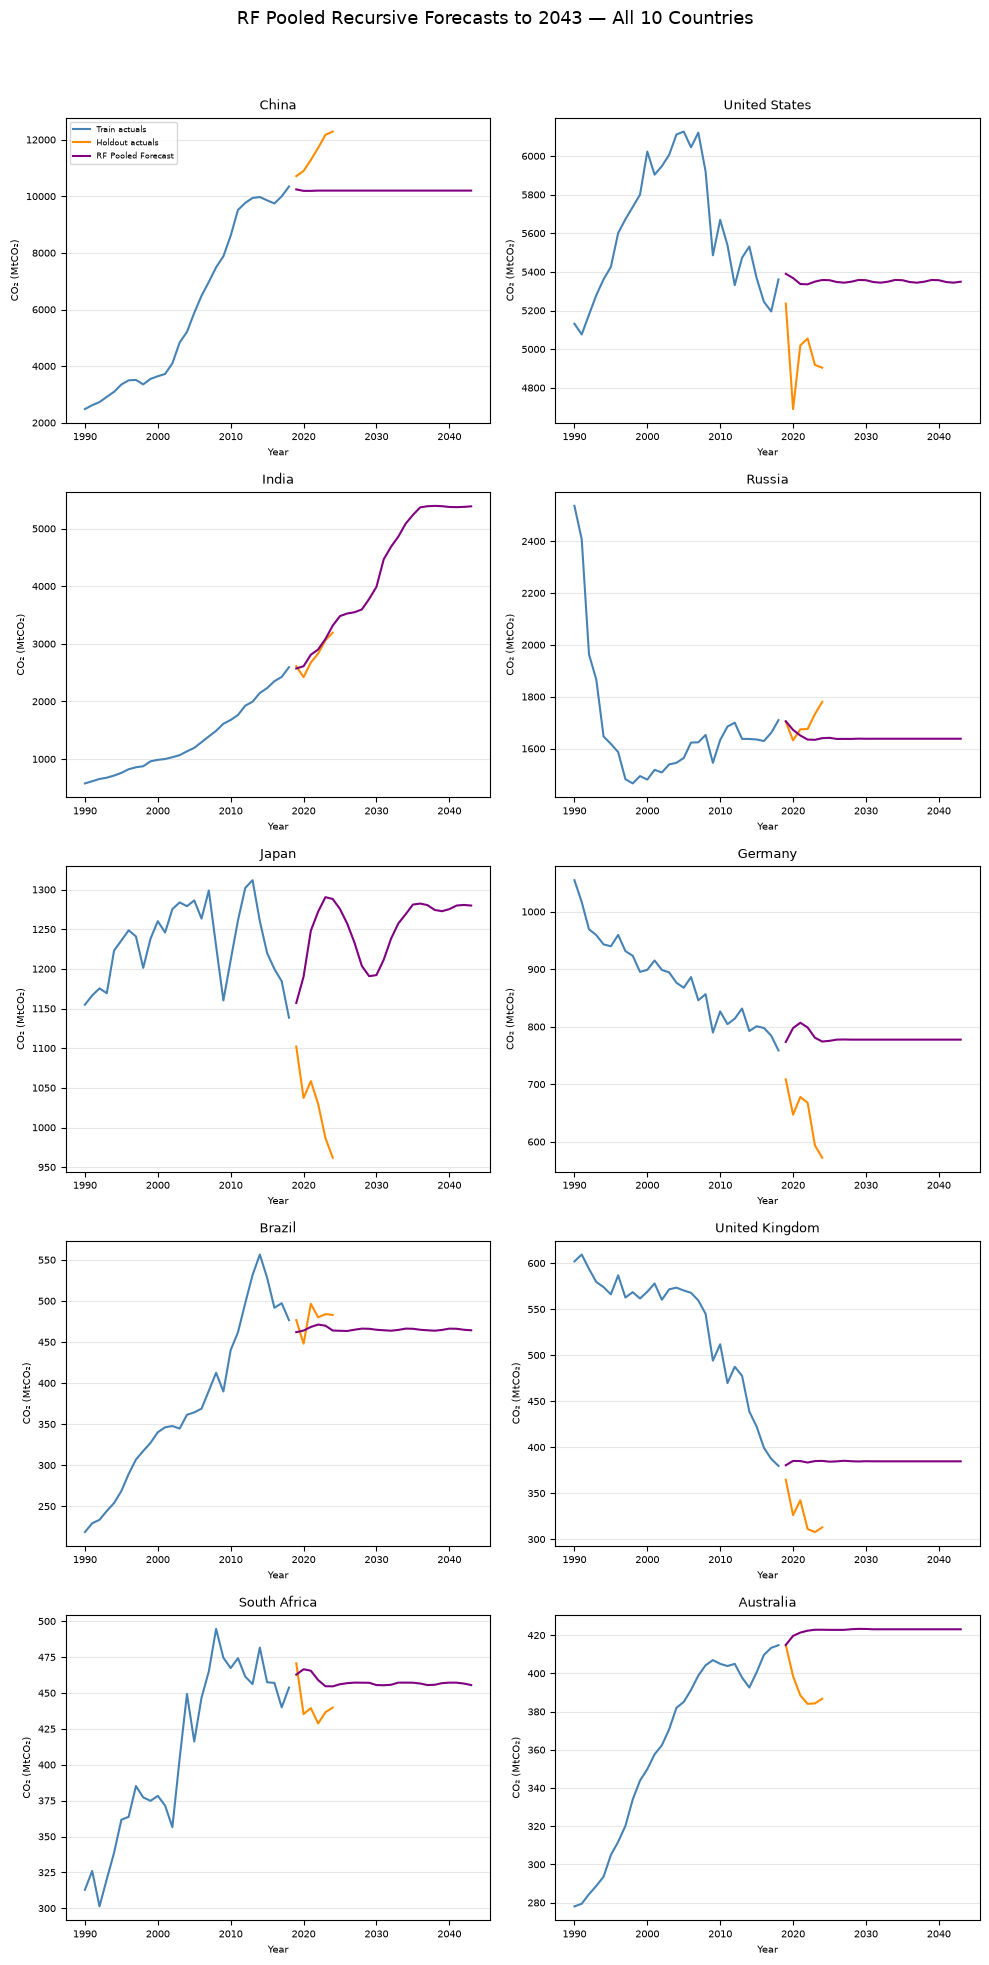

In [10]:
def build_forecast_features(history, yr):
    """Build one FEATURES row for forecast year yr using history dict {year: co2}."""
    recent = [history[yr - k] for k in range(1, 6) if (yr - k) in history]
    rolling_mean = np.mean(recent) if recent else np.nan
    prev, prev2 = history.get(yr - 1), history.get(yr - 2)
    yoy = ((prev - prev2) / prev2 * 100) if (prev is not None and prev2) else 0.0
    return {
        'years_since_1990':     yr - 1990,
        'co2_5yr_rolling_mean': rolling_mean,
        'co2_lag1':             history.get(yr - 1, np.nan),
        'co2_lag2':             history.get(yr - 2, np.nan),
        'co2_lag3':             history.get(yr - 3, np.nan),
        'co2_yoy_pct_change':   yoy,
    }

fc_years = np.arange(TRAIN_CUTOFF + 1, FORECAST_END + 1)  # 2019–2043

rf_forecasts_fc = {}

for country in COUNTRIES:
    base_hist = dict(zip(
        df_filtered[(df_filtered['country'] == country) & (df_filtered['year'] <= TRAIN_CUTOFF)]['year'],
        df_filtered[(df_filtered['country'] == country) & (df_filtered['year'] <= TRAIN_CUTOFF)]['co2'],
    ))

    rf_hist = dict(base_hist)
    rf_preds_fc = {}
    c_enc = le.transform([country])[0]

    for yr in fc_years:
        row_rf = {**build_forecast_features(rf_hist, yr), 'country_encoded': c_enc}
        rf_pred = rf_model.predict(pd.DataFrame([row_rf], columns=RF_FEATURES))[0]
        rf_preds_fc[yr] = rf_pred
        rf_hist[yr] = rf_pred

    rf_forecasts_fc[country] = pd.Series(rf_preds_fc)

fig, axes = plt.subplots(5, 2, figsize=(10, 20))
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, COUNTRIES):
    series  = df_filtered[df_filtered['country'] == country].sort_values('year').set_index('year')['co2']
    test_c  = test[test['country'] == country].set_index('year')['co2']
    train_s = series[series.index <= TRAIN_CUTOFF]

    ax.plot(train_s.index,                  train_s,                  color='steelblue',  lw=1.5,          label='Train actuals')
    ax.plot(test_c.index,                   test_c,                   color='darkorange', lw=1.5,          label='Holdout actuals')
    ax.plot(rf_forecasts_fc[country].index, rf_forecasts_fc[country], color='purple',     lw=1.5,          label='RF Pooled Forecast')
    ax.set_title(country, fontsize=9)
    ax.set_xlabel('Year', fontsize=7)
    ax.set_ylabel('CO\u2082 (MtCO\u2082)', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', alpha=0.3)

axes_flat[0].legend(fontsize=6, loc='upper left')
plt.suptitle('RF Pooled Recursive Forecasts to 2043 — All 10 Countries', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
